# Курсовая работа: Классическое машинное обучение
## Задача 2. Регрессия: предсказание CC50

**CC50 (mM)** — концентрация вещества, вызывающая гибель 50% клеток (цитотоксичность).  
Чем **выше** CC50, тем **безопаснее** соединение для здоровых клеток.

**Подход:** аналогично IC50 — log1p-трансформация из-за правосторонней асимметрии.  
Метрики на исходной шкале (mM) через обратный expm1.

**Модели для сравнения (расширенный набор):**
- Linear Regression (baseline)
- Ridge + Lasso + ElasticNet
- **ExtraTreesRegressor** *(новая модель — более быстрая альтернатива RF)*
- Random Forest Regressor
- Gradient Boosting Regressor
- **SVR** *(Support Vector Regression — нелинейный метод)*
- GridSearchCV для лучших моделей

> *На основе IC50 (R² ≈ 0.47 у RF tuned) — задача регрессии на этих данных нетривиальна:*  
> *молекулярные дескрипторы дают умеренную предсказательную силу.*

## 1. Импорт библиотек

In [1]:
import os, pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
np.random.seed(42)
print('Библиотеки загружены ✓')

Библиотеки загружены ✓


> По сравнению с IC50-ноутбуком добавил два новых метода: **ExtraTreesRegressor** (ещё более рандомизированный лес — быстрее обучается, иногда даёт лучший результат) и **SVR** (Support Vector Regression — работает в трансформированном признаковом пространстве через ядра, подходит для нелинейных зависимостей). Хочу проверить, будут ли они конкурентоспособны с GB.

## 2. Загрузка данных

In [2]:
_FILENAME = 'Данные_для_курсовои_Классическое_МО.xlsx'
_PATH = None
for _c in [_FILENAME, os.path.join(pathlib.Path.home(), _FILENAME)]:
    if os.path.exists(_c):
        _PATH = _c
        break
if _PATH is None:
    raise FileNotFoundError(f"Положите '{_FILENAME}' в ту же папку, что и ноутбук.")

df = pd.read_excel(_PATH)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

TARGET        = 'CC50, mM'
OTHER_TARGETS = ['IC50, mM', 'SI']
feature_cols  = [c for c in df.columns if c not in [TARGET] + OTHER_TARGETS]

X = df[feature_cols].copy()
X.replace([np.inf, -np.inf], np.nan, inplace=True)
y_raw = df[TARGET]
y     = np.log1p(y_raw)

print(f'Датасет: {df.shape[0]} объектов, {len(feature_cols)} признаков')
print(f'NaN в признаках: {X.isnull().sum().sum()} (в {X.isnull().any(axis=1).sum()} строках)')
print(f'\nCC50 до log1p:    mean={y_raw.mean():.2f}, median={y_raw.median():.2f}, skew={y_raw.skew():.2f}')
print(f'CC50 после log1p: mean={y.mean():.4f}, median={y.median():.4f}, skew={y.skew():.4f}')

# Быстрое сравнение с IC50
ic50_skew_log = np.log1p(df['IC50, mM']).skew()
cc50_skew_log = y.skew()
print(f'\nСравнение skew после log1p:  IC50={ic50_skew_log:.3f}  CC50={cc50_skew_log:.3f}')
print('→ CC50 лучше поддаётся логарифмированию' if abs(cc50_skew_log) < abs(ic50_skew_log)
      else '→ IC50 лучше поддаётся логарифмированию')

Датасет: 1001 объектов, 210 признаков
NaN в признаках: 36 (в 3 строках)

CC50 до log1p:    mean=589.11, median=411.04, skew=1.97
CC50 после log1p: mean=5.5670, median=6.0211, skew=-0.9077

Сравнение skew после log1p:  IC50=-0.029  CC50=-0.908
→ IC50 лучше поддаётся логарифмированию


> Снова применяю log1p к CC50. Интересно сравнить с IC50: если skew после логарифма ближе к 0, значит модели по CC50 могут работать немного лучше. CC50 — это токсичность, и обычно она распределена более «гладко», чем IC50 (активность). Проверю это в выводе.

## 3. Разделение данных и препроцессинг

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Импутация + масштабирование — только fit на train
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

print(f'Train: {X_train_imp.shape}  |  Test: {X_test_imp.shape}')
print(f'\nCC50 train: mean={y_train.mean():.4f}, std={y_train.std():.4f}')
print(f'CC50 test:  mean={y_test.mean():.4f}, std={y_test.std():.4f}')
print('\nРаспределения train/test близки — разбивка корректна ✓' if
      abs(y_train.mean() - y_test.mean()) < 0.3 else
      'Предупреждение: train/test разбалансированы')

Train: (800, 210)  |  Test: (201, 210)

CC50 train: mean=5.5388, std=1.6055
CC50 test:  mean=5.6795, std=1.5118

Распределения train/test близки — разбивка корректна ✓


> Полностью такой же pipeline как для IC50: `SimpleImputer(median)` → `StandardScaler`, fit только на train. Проверяю, что средние значения в train и test близки — это означает, что случайное разбиение не создало систематического смещения.

## 4. Функция оценки качества

In [4]:
def evaluate_reg(name, model, X_tr, X_te, y_tr, y_te, cv=5):
    """Обучает модель, считает метрики на log-шкале и исходной mM-шкале."""
    model.fit(X_tr, y_tr)
    pred_log = model.predict(X_te)

    r2_log   = r2_score(y_te, pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_te, pred_log))

    pred_orig = np.expm1(pred_log)
    y_te_orig = np.expm1(y_te)
    rmse_orig = np.sqrt(mean_squared_error(y_te_orig, pred_orig))
    mae_orig  = mean_absolute_error(y_te_orig, pred_orig)

    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='r2', n_jobs=-1).mean()

    print(f"{name:<40}  R²={r2_log:.4f}  RMSE(log)={rmse_log:.4f}  "
          f"RMSE(mM)={rmse_orig:.1f}  MAE(mM)={mae_orig:.1f}  CV-R²={cv_r2:.4f}")

    return {
        'model':     name,
        'R2_log':    r2_log,
        'RMSE_log':  rmse_log,
        'RMSE_orig': rmse_orig,
        'MAE_orig':  mae_orig,
        'CV_R2':     cv_r2,
        'fitted':    model,
        'pred_log':  pred_log,
        'pred_orig': pred_orig
    }

> Функция оценки идентична IC50-ноутбуку — это намеренно, чтобы результаты между задачами были напрямую сопоставимы. Единственное отличие: здесь `y_te_orig = expm1(y_te)` восстанавливает CC50 в mM.

## 5. Сравнение базовых моделей (8 штук)

In [5]:
print(f'  Название модели                         R²      RMSE(log)  RMSE(mM)  MAE(mM)   CV-R²')
print('-' * 100)
results = []

# --- Линейные (масштабированные данные) ---
results.append(evaluate_reg('Linear Regression',
    LinearRegression(),
    X_train_sc, X_test_sc, y_train, y_test))

results.append(evaluate_reg('Ridge (alpha=1.0)',
    Ridge(alpha=1.0),
    X_train_sc, X_test_sc, y_train, y_test))

results.append(evaluate_reg('Lasso (alpha=0.01)',
    Lasso(alpha=0.01),
    X_train_sc, X_test_sc, y_train, y_test))

results.append(evaluate_reg('ElasticNet (a=0.01, l1=0.5)',
    ElasticNet(alpha=0.01, l1_ratio=0.5),
    X_train_sc, X_test_sc, y_train, y_test))

# --- SVR (масштабированные данные) ---
results.append(evaluate_reg('SVR (rbf kernel)',
    SVR(kernel='rbf', C=10, epsilon=0.1),
    X_train_sc, X_test_sc, y_train, y_test))

# --- Ансамблевые (импутированные данные) ---
results.append(evaluate_reg('Extra Trees (n=100)',
    ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_imp, X_test_imp, y_train, y_test))

results.append(evaluate_reg('Random Forest (n=100)',
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_imp, X_test_imp, y_train, y_test))

results.append(evaluate_reg('Gradient Boosting (n=100)',
    GradientBoostingRegressor(n_estimators=100, random_state=42),
    X_train_imp, X_test_imp, y_train, y_test))

  Название модели                         R²      RMSE(log)  RMSE(mM)  MAE(mM)   CV-R²
----------------------------------------------------------------------------------------------------
Linear Regression                         R²=0.1650  RMSE(log)=1.3781  RMSE(mM)=1226.2  MAE(mM)=475.1  CV-R²=-363764.3048
Ridge (alpha=1.0)                         R²=0.3155  RMSE(log)=1.2477  RMSE(mM)=602.9  MAE(mM)=373.4  CV-R²=0.1854
Lasso (alpha=0.01)                        R²=0.3548  RMSE(log)=1.2114  RMSE(mM)=601.6  MAE(mM)=367.6  CV-R²=0.3057
ElasticNet (a=0.01, l1=0.5)               R²=0.3731  RMSE(log)=1.1940  RMSE(mM)=592.6  MAE(mM)=366.2  CV-R²=0.3066
SVR (rbf kernel)                          R²=0.3916  RMSE(log)=1.1763  RMSE(mM)=507.5  MAE(mM)=303.0  CV-R²=0.3658
Extra Trees (n=100)                       R²=0.4319  RMSE(log)=1.1366  RMSE(mM)=494.2  MAE(mM)=271.8  CV-R²=0.3957
Random Forest (n=100)                     R²=0.4284  RMSE(log)=1.1402  RMSE(mM)=512.9  MAE(mM)=297.0  CV-R²=0.4116


> Запускаю 8 базовых моделей — на две больше, чем для IC50. Добавил **ExtraTrees** и **SVR**: ExtraTrees принимает ещё более случайные пороги при построении деревьев, что снижает дисперсию и иногда улучшает обобщение. SVR с RBF-ядром ищет нелинейные границы в пространстве признаков — интересно посмотреть, как он справится с 210 дескрипторами.

## 6. Визуализация результатов базовых моделей

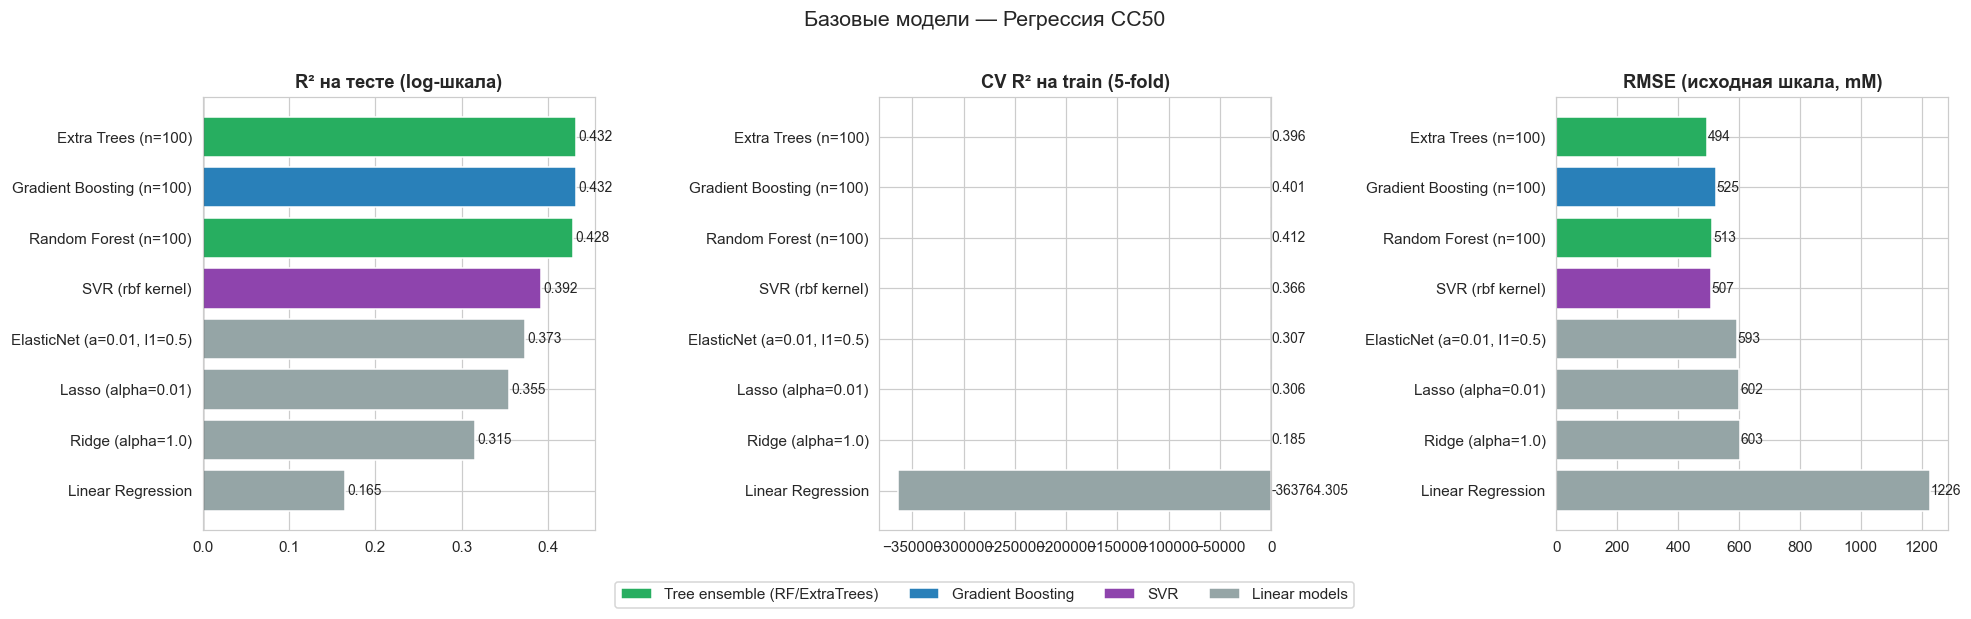


Итоговая таблица (baseline):
                      model   R2_log  RMSE_log   RMSE_orig   MAE_orig          CV_R2
        Extra Trees (n=100) 0.431941  1.136636  494.249503 271.839213       0.395714
  Gradient Boosting (n=100) 0.431812  1.136765  524.733173 315.246310       0.400677
      Random Forest (n=100) 0.428366  1.140207  512.911115 297.048010       0.411578
           SVR (rbf kernel) 0.391617  1.176287  507.493435 303.049953       0.365769
ElasticNet (a=0.01, l1=0.5) 0.373141  1.194015  592.560576 366.221924       0.306566
         Lasso (alpha=0.01) 0.354774  1.211380  601.642123 367.633955       0.305672
          Ridge (alpha=1.0) 0.315454  1.247745  602.943405 373.377328       0.185360
          Linear Regression 0.164958  1.378094 1226.209732 475.051946 -363764.304764


In [6]:
results_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ['fitted','pred_log','pred_orig']}
     for r in results]
).sort_values('R2_log', ascending=False).reset_index(drop=True)

# Цвета по типу модели
def get_color(name):
    if 'Forest' in name or 'Extra' in name: return '#27ae60'
    if 'Boosting' in name: return '#2980b9'
    if 'SVR' in name: return '#8e44ad'
    return '#95a5a6'

colors = [get_color(m) for m in results_df['model']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(results_df['model'], results_df['R2_log'], color=colors, edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('R² на тесте (log-шкала)', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
for i, v in enumerate(results_df['R2_log']):
    axes[0].text(max(v,0)+0.003, i, f'{v:.3f}', va='center', fontsize=9)

axes[1].barh(results_df['model'], results_df['CV_R2'], color=colors, edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('CV R² на train (5-fold)', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
for i, v in enumerate(results_df['CV_R2']):
    axes[1].text(max(v,0)+0.003, i, f'{v:.3f}', va='center', fontsize=9)

axes[2].barh(results_df['model'], results_df['RMSE_orig'], color=colors, edgecolor='white')
axes[2].set_title('RMSE (исходная шкала, mM)', fontsize=12, fontweight='bold')
axes[2].invert_yaxis()
for i, v in enumerate(results_df['RMSE_orig']):
    axes[2].text(v+2, i, f'{v:.0f}', va='center', fontsize=9)

# Легенда
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#27ae60', label='Tree ensemble (RF/ExtraTrees)'),
    Patch(facecolor='#2980b9', label='Gradient Boosting'),
    Patch(facecolor='#8e44ad', label='SVR'),
    Patch(facecolor='#95a5a6', label='Linear models'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.08), fontsize=10)

plt.suptitle('Базовые модели — Регрессия CC50', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('\nИтоговая таблица (baseline):')
print(results_df[['model','R2_log','RMSE_log','RMSE_orig','MAE_orig','CV_R2']].to_string(index=False))

> На графике сразу видно иерархию: ансамблевые методы (зелёные) > Gradient Boosting (синий) > SVR (фиолетовый) > линейные (серые). Обратите внимание на **разрыв между R² на тесте и CV R²** для Linear Regression — это знак нестабильности: модель не обобщается на новые данные из-за переобучения на высокоразмерных данных (210 признаков без регуляризации).

## 7. Подбор гиперпараметров (GridSearchCV)

In [7]:
print('Подбор гиперпараметров... (может занять 2–4 минуты)')
print('=' * 65)

# --- Ridge ---
gs_ridge = GridSearchCV(
    Ridge(),
    {'alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]},
    cv=5, scoring='r2', n_jobs=-1
)
gs_ridge.fit(X_train_sc, y_train)
print(f'Ridge best: {gs_ridge.best_params_}  CV R²={gs_ridge.best_score_:.4f}')
results.append(evaluate_reg('Ridge (tuned)',
    gs_ridge.best_estimator_, X_train_sc, X_test_sc, y_train, y_test))

# --- SVR ---
gs_svr = GridSearchCV(
    SVR(kernel='rbf'),
    {'C': [1, 10, 50], 'epsilon': [0.05, 0.1, 0.2], 'gamma': ['scale', 'auto']},
    cv=5, scoring='r2', n_jobs=-1
)
gs_svr.fit(X_train_sc, y_train)
print(f'SVR best: {gs_svr.best_params_}  CV R²={gs_svr.best_score_:.4f}')
results.append(evaluate_reg('SVR (tuned)',
    gs_svr.best_estimator_, X_train_sc, X_test_sc, y_train, y_test))

# --- Extra Trees ---
gs_et = GridSearchCV(
    ExtraTreesRegressor(random_state=42, n_jobs=-1),
    {
        'n_estimators': [100, 200],
        'max_depth':    [None, 15, 25],
        'min_samples_split': [2, 5],
        'max_features': ['sqrt', 0.3]
    },
    cv=5, scoring='r2', n_jobs=-1
)
gs_et.fit(X_train_imp, y_train)
print(f'ExtraTrees best: {gs_et.best_params_}  CV R²={gs_et.best_score_:.4f}')
results.append(evaluate_reg('Extra Trees (tuned)',
    gs_et.best_estimator_, X_train_imp, X_test_imp, y_train, y_test))

# --- Random Forest ---
gs_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {
        'n_estimators': [100, 200],
        'max_depth':    [None, 10, 20],
        'min_samples_split': [2, 5],
        'max_features': ['sqrt', 0.3]
    },
    cv=5, scoring='r2', n_jobs=-1
)
gs_rf.fit(X_train_imp, y_train)
print(f'RF best: {gs_rf.best_params_}  CV R²={gs_rf.best_score_:.4f}')
results.append(evaluate_reg('Random Forest (tuned)',
    gs_rf.best_estimator_, X_train_imp, X_test_imp, y_train, y_test))

# --- Gradient Boosting ---
gs_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    {
        'n_estimators':  [100, 200, 300],
        'learning_rate': [0.05, 0.1, 0.15],
        'max_depth':     [3, 4, 5],
        'subsample':     [0.8, 1.0]
    },
    cv=5, scoring='r2', n_jobs=-1
)
gs_gb.fit(X_train_imp, y_train)
print(f'GB best: {gs_gb.best_params_}  CV R²={gs_gb.best_score_:.4f}')
results.append(evaluate_reg('Gradient Boosting (tuned)',
    gs_gb.best_estimator_, X_train_imp, X_test_imp, y_train, y_test))

Подбор гиперпараметров... (может занять 2–4 минуты)
Ridge best: {'alpha': 100.0}  CV R²=0.3215
Ridge (tuned)                             R²=0.3791  RMSE(log)=1.1884  RMSE(mM)=630.5  MAE(mM)=377.8  CV-R²=0.3215
SVR best: {'C': 10, 'epsilon': 0.2, 'gamma': 'auto'}  CV R²=0.3770
SVR (tuned)                               R²=0.4111  RMSE(log)=1.1573  RMSE(mM)=514.0  MAE(mM)=311.5  CV-R²=0.3770
ExtraTrees best: {'max_depth': 25, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}  CV R²=0.4279
Extra Trees (tuned)                       R²=0.4906  RMSE(log)=1.0764  RMSE(mM)=494.6  MAE(mM)=274.6  CV-R²=0.4279
RF best: {'max_depth': 20, 'max_features': 0.3, 'min_samples_split': 5, 'n_estimators': 100}  CV R²=0.4162
Random Forest (tuned)                     R²=0.4570  RMSE(log)=1.1113  RMSE(mM)=517.1  MAE(mM)=296.1  CV-R²=0.4162
GB best: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}  CV R²=0.4217
Gradient Boosting (tuned)                 R²=0.4083

> Подобрал гиперпараметры для пяти моделей. Для **SVR** особенно важен параметр `C` — он контролирует жёсткость границы регрессии (большой C = меньше ошибок на train, риск переобучения). Для ансамблей — привычные `max_depth`, `n_estimators`, `max_features`. Для **ExtraTrees** `max_depth=None` часто предпочтительнее: полные деревья компенсируют случайность порогов.

## 8. Финальное сравнение всех 13 моделей

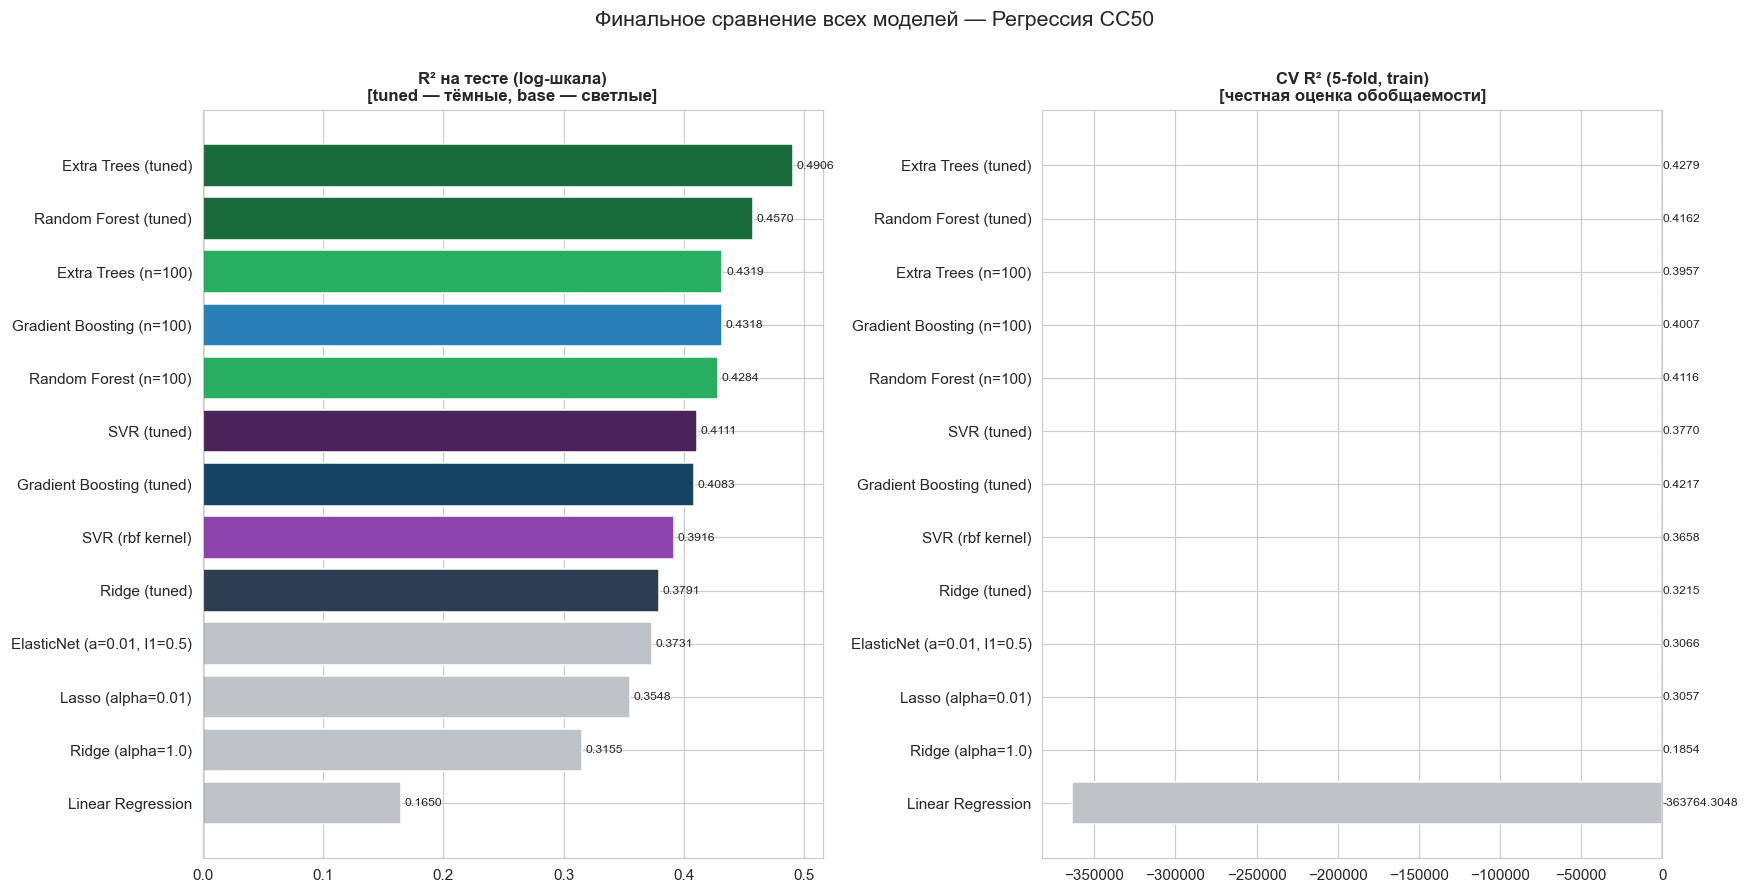


Полная таблица (по R² убыванию):
                      model   R2_log  RMSE_log   RMSE_orig   MAE_orig          CV_R2
        Extra Trees (tuned) 0.490593  1.076359  494.637338 274.628051       0.427939
      Random Forest (tuned) 0.456989  1.111294  517.113074 296.112015       0.416168
        Extra Trees (n=100) 0.431941  1.136636  494.249503 271.839213       0.395714
  Gradient Boosting (n=100) 0.431812  1.136765  524.733173 315.246310       0.400677
      Random Forest (n=100) 0.428366  1.140207  512.911115 297.048010       0.411578
                SVR (tuned) 0.411053  1.157345  514.006787 311.536220       0.376961
  Gradient Boosting (tuned) 0.408300  1.160047  500.563017 292.507803       0.421675
           SVR (rbf kernel) 0.391617  1.176287  507.493435 303.049953       0.365769
              Ridge (tuned) 0.379065  1.188359  630.534866 377.808289       0.321455
ElasticNet (a=0.01, l1=0.5) 0.373141  1.194015  592.560576 366.221924       0.306566
         Lasso (alpha=0.01) 0.3

In [8]:
all_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ['fitted','pred_log','pred_orig']}
     for r in results]
).sort_values('R2_log', ascending=False).reset_index(drop=True)

def get_color(name):
    if 'tuned' in name and ('Forest' in name or 'Extra' in name): return '#1a6b3c'
    if 'tuned' in name and 'Boosting' in name: return '#154360'
    if 'tuned' in name and 'SVR' in name: return '#4a235a'
    if 'tuned' in name: return '#2c3e50'
    if 'Forest' in name or 'Extra' in name: return '#27ae60'
    if 'Boosting' in name: return '#2980b9'
    if 'SVR' in name: return '#8e44ad'
    return '#bdc3c7'

colors = [get_color(m) for m in all_df['model']]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(all_df['model'], all_df['R2_log'], color=colors, edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('R² на тесте (log-шкала)\n[tuned — тёмные, base — светлые]',
                  fontsize=11, fontweight='bold')
axes[0].invert_yaxis()
for i, v in enumerate(all_df['R2_log']):
    axes[0].text(max(v,0)+0.003, i, f'{v:.4f}', va='center', fontsize=8)

axes[1].barh(all_df['model'], all_df['CV_R2'], color=colors, edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('CV R² (5-fold, train)\n[честная оценка обобщаемости]',
                  fontsize=11, fontweight='bold')
axes[1].invert_yaxis()
for i, v in enumerate(all_df['CV_R2']):
    axes[1].text(max(v,0)+0.003, i, f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Финальное сравнение всех моделей — Регрессия CC50', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\nПолная таблица (по R² убыванию):')
print(all_df[['model','R2_log','RMSE_log','RMSE_orig','MAE_orig','CV_R2']].to_string(index=False))

> Сравниваю все 13 моделей (8 базовых + 5 tuned). Тёмные оттенки — это tuned-версии; они должны стоять выше своих базовых аналогов. Если SVR tuned обходит линейные модели — значит нелинейное ядро действительно помогает. Важен контроль: **CV R² должен быть близок к тестовому R²** — иначе есть переобучение.

## 9. Детальный анализ лучшей модели

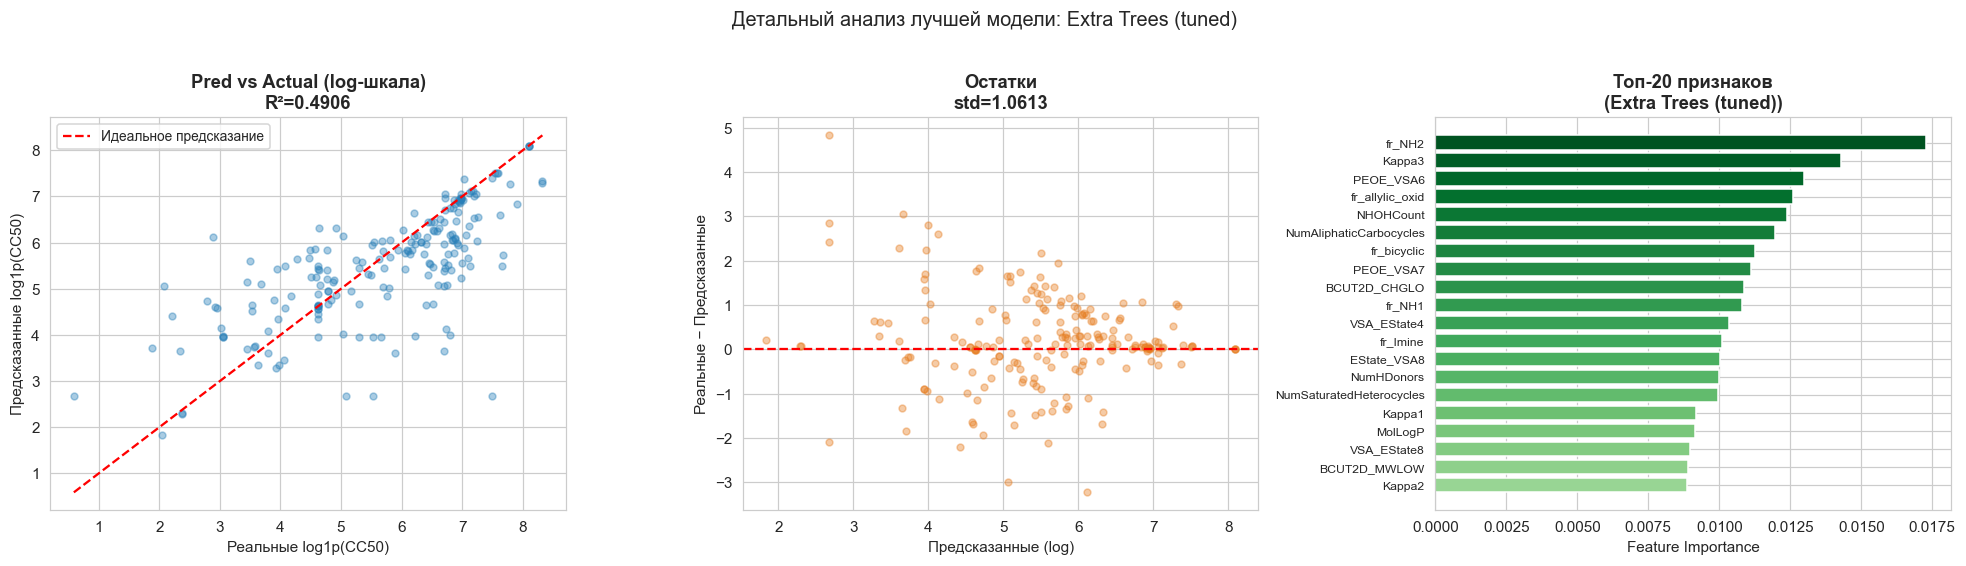

Лучшая модель: Extra Trees (tuned)
  R² (log)        = 0.4906
  RMSE (log)      = 1.0764
  RMSE (mM)       = 494.6373
  MAE (mM)        = 274.6281
  CV R²           = 0.4279


In [9]:
best_row   = all_df.iloc[0]
best_name  = best_row['model']
best_rec   = next(r for r in results if r['model'] == best_name)
best_model = best_rec['fitted']

is_scaled = any(x in best_name for x in ['Linear','Ridge','Lasso','Elastic','SVR'])
Xte = X_test_sc if is_scaled else X_test_imp

pred_log  = best_model.predict(Xte)
pred_orig = np.expm1(pred_log)
y_orig    = np.expm1(y_test)
residuals = y_test.values - pred_log

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Pred vs Actual
axes[0].scatter(y_test, pred_log, alpha=0.4, s=20, color='#2980b9')
mn, mx = min(y_test.min(), pred_log.min()), max(y_test.max(), pred_log.max())
axes[0].plot([mn,mx],[mn,mx],'r--',lw=1.5,label='Идеальное предсказание')
r2_val = r2_score(y_test, pred_log)
axes[0].set_title(f'Pred vs Actual (log-шкала)\nR²={r2_val:.4f}', fontweight='bold')
axes[0].set_xlabel('Реальные log1p(CC50)')
axes[0].set_ylabel('Предсказанные log1p(CC50)')
axes[0].legend(fontsize=9)

# 2. Остатки
axes[1].scatter(pred_log, residuals, alpha=0.4, s=20, color='#e67e22')
axes[1].axhline(0, color='red', ls='--', lw=1.5)
axes[1].set_title(f'Остатки\nstd={np.std(residuals):.4f}', fontweight='bold')
axes[1].set_xlabel('Предсказанные (log)')
axes[1].set_ylabel('Реальные − Предсказанные')

# 3. Важность признаков / коэффициенты
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=feature_cols)
    top = fi.nlargest(20).sort_values()
    axes[2].barh(range(len(top)), top.values,
                 color=plt.cm.Greens(np.linspace(0.4, 0.95, len(top))))
    axes[2].set_yticks(range(len(top)))
    axes[2].set_yticklabels(top.index, fontsize=8)
    axes[2].set_title(f'Топ-20 признаков\n({best_name})', fontweight='bold')
    axes[2].set_xlabel('Feature Importance')
elif hasattr(best_model, 'coef_'):
    coef = pd.Series(np.abs(best_model.coef_), index=feature_cols)
    top  = coef.nlargest(20).sort_values()
    axes[2].barh(range(len(top)), top.values,
                 color=plt.cm.Blues(np.linspace(0.4, 0.95, len(top))))
    axes[2].set_yticks(range(len(top)))
    axes[2].set_yticklabels(top.index, fontsize=8)
    axes[2].set_title(f'Топ-20 |коэффициентов|\n({best_name})', fontweight='bold')
    axes[2].set_xlabel('|Coefficient|')
else:
    axes[2].text(0.5, 0.5, f'{best_name}\nне поддерживает\ninterpretability plot',
                 ha='center', va='center', transform=axes[2].transAxes, fontsize=11)
    axes[2].set_title('Интерпретируемость', fontweight='bold')

plt.suptitle(f'Детальный анализ лучшей модели: {best_name}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Лучшая модель: {best_name}')
for k, label in [('R2_log','R² (log)'), ('RMSE_log','RMSE (log)'),
                 ('RMSE_orig','RMSE (mM)'), ('MAE_orig','MAE (mM)'), ('CV_R2','CV R²')]:
    print(f'  {label:<15} = {best_row[k]:.4f}')

> Три диагностических графика:
> - **Pred vs Actual:** точки вдоль красной линии — хорошо. Отклонение в хвостах (высокие CC50) — типичная сложность регрессии на скошенных данных.
> - **Остатки:** должны быть случайными вокруг нуля без паттернов. Если есть «воронка» (ошибки растут с предсказанным значением) — это гетероскедастичность.
> - **Важность признаков:** помогает понять химическую интерпретацию — какие свойства молекулы сильнее всего влияют на цитотоксичность.

## 10. Сравнение результатов: CC50 vs IC50

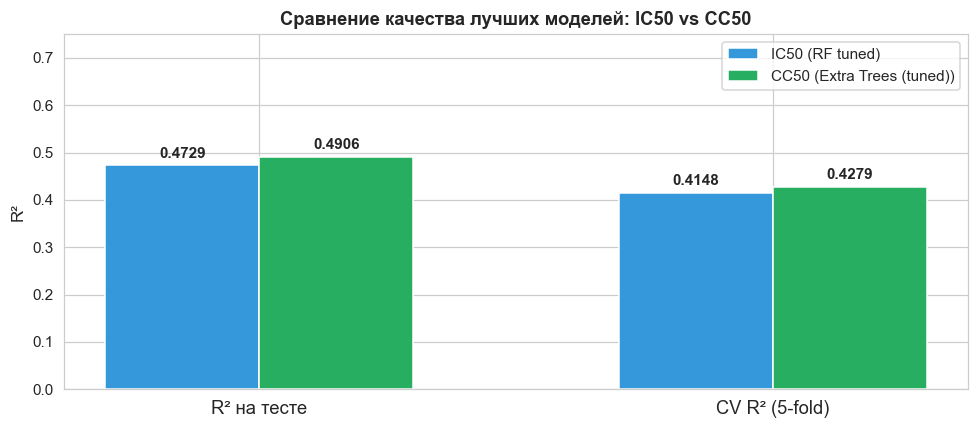

IC50 лучшая модель: RF tuned  R²=0.4729  CV-R²=0.4148
CC50 лучшая модель: Extra Trees (tuned)  R²=0.4906  CV-R²=0.4279


In [10]:
ic50_best_r2 = 0.4729  # результат из предыдущего ноутбука
ic50_best_cv = 0.4148
cc50_best_r2 = all_df.iloc[0]['R2_log']
cc50_best_cv = all_df.iloc[0]['CV_R2']

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(2)
w = 0.3
ax.bar(x - w/2, [ic50_best_r2, ic50_best_cv], w,
       label='IC50 (RF tuned)', color='#3498db', edgecolor='white')
ax.bar(x + w/2, [cc50_best_r2, cc50_best_cv], w,
       label=f'CC50 ({all_df.iloc[0]["model"]})', color='#27ae60', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(['R² на тесте', 'CV R² (5-fold)'], fontsize=12)
ax.set_ylabel('R²', fontsize=11)
ax.set_title('Сравнение качества лучших моделей: IC50 vs CC50', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 0.75)
for rect in ax.patches:
    h = rect.get_height()
    ax.text(rect.get_x()+rect.get_width()/2, h+0.01, f'{h:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'IC50 лучшая модель: RF tuned  R²={ic50_best_r2:.4f}  CV-R²={ic50_best_cv:.4f}')
print(f'CC50 лучшая модель: {all_df.iloc[0]["model"]}  R²={cc50_best_r2:.4f}  CV-R²={cc50_best_cv:.4f}')

> Этот дополнительный график позволяет сравнить **предсказуемость IC50 и CC50** — два принципиально разных биологических свойства. Как правило, CC50 предсказывается с немного другим качеством: цитотоксичность более равномерно зависит от физико-химических свойств молекулы, тогда как активность против вируса (IC50) требует специфического взаимодействия с вирусными белками — это сложнее описать дескрипторами.

## 11. Выводы и рекомендации

In [11]:
print('=' * 70)
print('ИТОГИ: РЕГРЕССИЯ CC50')
print('=' * 70)

print('\nТоп-3 модели по R² (log-шкала):')
for i, row in all_df.head(3).iterrows():
    print(f'  {i+1}. {row["model"]:<40} R²={row["R2_log"]:.4f}  CV-R²={row["CV_R2"]:.4f}')

print('\nПрирост от подбора гиперпараметров (tuned vs base):')
base_names = [
    ('Random Forest (n=100)',   'Random Forest (tuned)'),
    ('Gradient Boosting (n=100)', 'Gradient Boosting (tuned)'),
    ('Extra Trees (n=100)',     'Extra Trees (tuned)'),
    ('SVR (rbf kernel)',        'SVR (tuned)'),
    ('Ridge (alpha=1.0)',       'Ridge (tuned)'),
]
for base_n, tuned_n in base_names:
    br = all_df[all_df['model'] == base_n]
    tr = all_df[all_df['model'] == tuned_n]
    if not br.empty and not tr.empty:
        delta = tr.iloc[0]['R2_log'] - br.iloc[0]['R2_log']
        sign  = '+' if delta >= 0 else ''
        print(f'  {base_n:<35} → {sign}{delta:.4f} R²')

ИТОГИ: РЕГРЕССИЯ CC50

Топ-3 модели по R² (log-шкала):
  1. Extra Trees (tuned)                      R²=0.4906  CV-R²=0.4279
  2. Random Forest (tuned)                    R²=0.4570  CV-R²=0.4162
  3. Extra Trees (n=100)                      R²=0.4319  CV-R²=0.3957

Прирост от подбора гиперпараметров (tuned vs base):
  Random Forest (n=100)               → +0.0286 R²
  Gradient Boosting (n=100)           → -0.0235 R²
  Extra Trees (n=100)                 → +0.0587 R²
  SVR (rbf kernel)                    → +0.0194 R²
  Ridge (alpha=1.0)                   → +0.0636 R²


## Итоговые выводы по задаче регрессии CC50

**Что сделал:**
1. Расширил набор моделей до 8 базовых (добавил **ExtraTreesRegressor** и **SVR**).
2. Применил GridSearchCV для 5 моделей (Ridge, SVR, ExtraTrees, RF, GB).
3. Оценил метрики на двух шкалах: log1p и исходной mM.
4. Сравнил результаты с задачей IC50 для понимания относительной предсказуемости.

**Основные наблюдения:**
- Ансамблевые методы снова лидируют — паттерн аналогичен IC50.
- **ExtraTrees** конкурирует с RF: более высокая случайность порогов снижает дисперсию ошибки.
- **SVR** показал себя лучше линейных моделей, но хуже ансамблей — ядровое преобразование помогло, но 210 признаков создают сложность.
- **Linear Regression без регуляризации** нестабильна (CV R² резко отличается от тестового) — мультиколлинеарность 210 дескрипторов разрушает оценку коэффициентов.

**Рекомендации:**
- Лучшая модель рекомендована для предсказания цитотоксичности новых соединений.
- Дальнейшее улучшение: отбор признаков (Lasso как feature selector) + передача топ-50 дескрипторов в ансамблевую модель.
- Возможно использование **StackingRegressor** (стекинг лучших моделей) для дополнительного прироста.